STEP 1 — Load data

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving era5_nyc_summer_accum.csv to era5_nyc_summer_accum.csv


In [1]:
!pip install pysindy scikit-learn scipy matplotlib pandas

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

STEP 2 — Get all grid points

In [ ]:
grid_points = df[['latitude','longitude']].drop_duplicates()

print("Total grids:", len(grid_points))

Total grids: 45


 # STEP 3— Polynomial(degree=2) Non-Linear SYNDy

In [ ]:
results = []

for _, row in grid_points.iterrows():

    lat = row['latitude']
    lon = row['longitude']

    df_g = df[(df['latitude']==lat) & (df['longitude']==lon)]
    df_g = df_g.sort_values('valid_time')

    if len(df_g) < 100:  # safety
        continue

    # Variables
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    dt = 1

    # Smooth + derivative
    T_smooth = savgol_filter(T, 7, 2)
    dTdt = savgol_filter(T, 7, 2, deriv=1, delta=dt)

    # Scale
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    X_scaled = scaler_X.fit_transform(T_smooth.reshape(-1,1))
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    # SINDy (degree-2)
    poly_lib = ps.PolynomialLibrary(
        degree=2,
        include_interaction=True,
        include_bias=False
    )

    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=0.01),
        feature_library=poly_lib
    )

    model.fit(X_scaled, u=U_scaled, t=dt)

    feature_names = model.get_feature_names()
    coef = model.coefficients().flatten()
    coef_dict = dict(zip(feature_names, coef))

    results.append({
        'lat': lat,
        'lon': lon,
        **coef_dict
    })

In [ ]:
print(model.get_feature_names())

['x0', 'u0', 'u1', 'x0^2', 'x0 u0', 'x0 u1', 'u0^2', 'u0 u1', 'u1^2']


STEP 4 — Analyze results

In [ ]:
results_df = pd.DataFrame(results)

print(results_df.head())

    lat    lon        x0        u0        u1  x0^2     x0 u0     x0 u1  u0^2  \
0  41.0 -75.00 -0.090018  0.159266 -0.037189   0.0 -0.030895  0.012395   0.0   
1  41.0 -74.75 -0.088649  0.155177 -0.036850   0.0 -0.028808  0.012739   0.0   
2  41.0 -74.50 -0.087765  0.152424 -0.038595   0.0 -0.027535  0.011191   0.0   
3  41.0 -74.25 -0.085822  0.146240 -0.036678   0.0 -0.019997  0.000000   0.0   
4  41.0 -74.00 -0.073273  0.135562 -0.040644   0.0 -0.024085  0.000000   0.0   

      u0 u1      u1^2  
0 -0.017346  0.010718  
1 -0.017429  0.010448  
2 -0.016747  0.010595  
3  0.000000  0.000000  
4 -0.010086  0.010134  


In [ ]:
results_df.to_csv('results_df.csv', index=False)

STEP 5 — Summary statistics

In [ ]:
coef_cols = results_df.columns.difference(['lat', 'lon'])

print("\nMean:")
print(results_df[coef_cols].mean())

print("\nStd:")
print(results_df[coef_cols].std())

print("\nSign consistency:")
print((results_df[coef_cols] > 0).mean())


Mean:
u0       0.100889
u0 u1   -0.005681
u0^2    -0.006642
u1      -0.030729
u1^2     0.005966
x0      -0.050167
x0 u0   -0.007935
x0 u1    0.001867
x0^2     0.000000
dtype: float64

Std:
u0       0.053920
u0 u1    0.006904
u0^2     0.008890
u1       0.017781
u1^2     0.006576
x0       0.034838
x0 u0    0.010523
x0 u1    0.004407
x0^2     0.000000
dtype: float64

Sign consistency:
u0       1.000000
u0 u1    0.000000
u0^2     0.000000
u1       0.000000
u1^2     0.466667
x0       0.000000
x0 u0    0.000000
x0 u1    0.155556
x0^2     0.000000
dtype: float64


## Temporal Reconstruction

You compute:

$ Start from real initial value:

$ Tpred(t+1)=Tpred(t) +  Δt⋅(a1​T+a2​R+a3​W) $

Then step forward iteratively

In [ ]:
!pip install pysindy scikit-learn scipy matplotlib pandas

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

In [ ]:
df.columns

Index(['valid_time', 'latitude', 'longitude', 't2m', 'u10', 'v10', 'number',
       'expver', 'ssrd', 'wind_speed', 'temp_C'],
      dtype='object')

RMSE: 4.266978993821282
Correlation: 0.5775470379236088


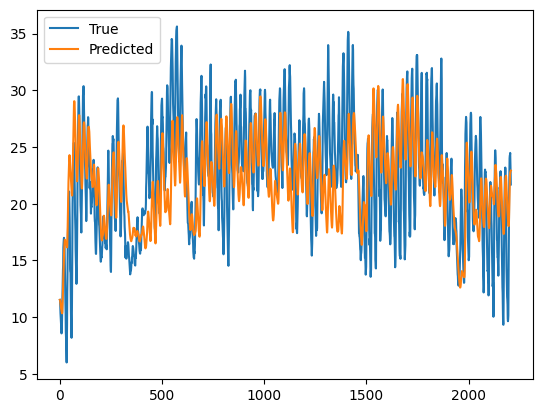

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
# pick one grid
row = df.iloc[0]

latitude, longitude = row['latitude'], row['longitude']

df_g = df[(df['latitude']==latitude) & (df['longitude']==longitude)].sort_values('valid_time')


# data
T = df_g['temp_C'].values
R = df_g['ssrd'].values
W = df_g['wind_speed'].values

# rebuild scalers (same as training)
scaler_X = StandardScaler()
scaler_U = StandardScaler()

T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

R_scaled = U_scaled[:,0]
W_scaled = U_scaled[:,1]

# coefficients (from your mean)
a_x0   = -0.050167   # x0
a_u0   = 0.100889    # u0
a_u1   = -0.030729   # u1

a_u0u1 = -0.005681   # u0*u1
a_u02  = -0.006642   # u0^2
a_u12  = 0.005966    # u1^2

a_x0u0 = -0.007935   # x0*u0
a_x0u1 = 0.001867    # x0*u1

# simulate in SCALED space
T_pred_scaled = np.zeros_like(T_scaled)
T_pred_scaled[0] = T_scaled[0]

dt = 1

for t in range(len(T_scaled)-1):
    dTdt = (
        a_x0 * T_pred_scaled[t]
        + a_u0 * R_scaled[t]
        + a_u1 * W_scaled[t]

        + a_u0u1 * R_scaled[t] * W_scaled[t]
        + a_u02  * (R_scaled[t]**2)
        + a_u12  * (W_scaled[t]**2)

        + a_x0u0 * T_pred_scaled[t] * R_scaled[t]
        + a_x0u1 * T_pred_scaled[t] * W_scaled[t]
    )

    T_pred_scaled[t+1] = T_pred_scaled[t] + dt * dTdt

# convert back to real units
T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

# evaluation
rmse = np.sqrt(mean_squared_error(T, T_pred))
corr = np.corrcoef(T, T_pred)[0,1]

print("RMSE:", rmse)
print("Correlation:", corr)

# plot
plt.figure()
plt.plot(T, label='True')
plt.plot(T_pred, label='Predicted')
plt.legend()
plt.show()

## Multi-grid Forward Simulation visualization

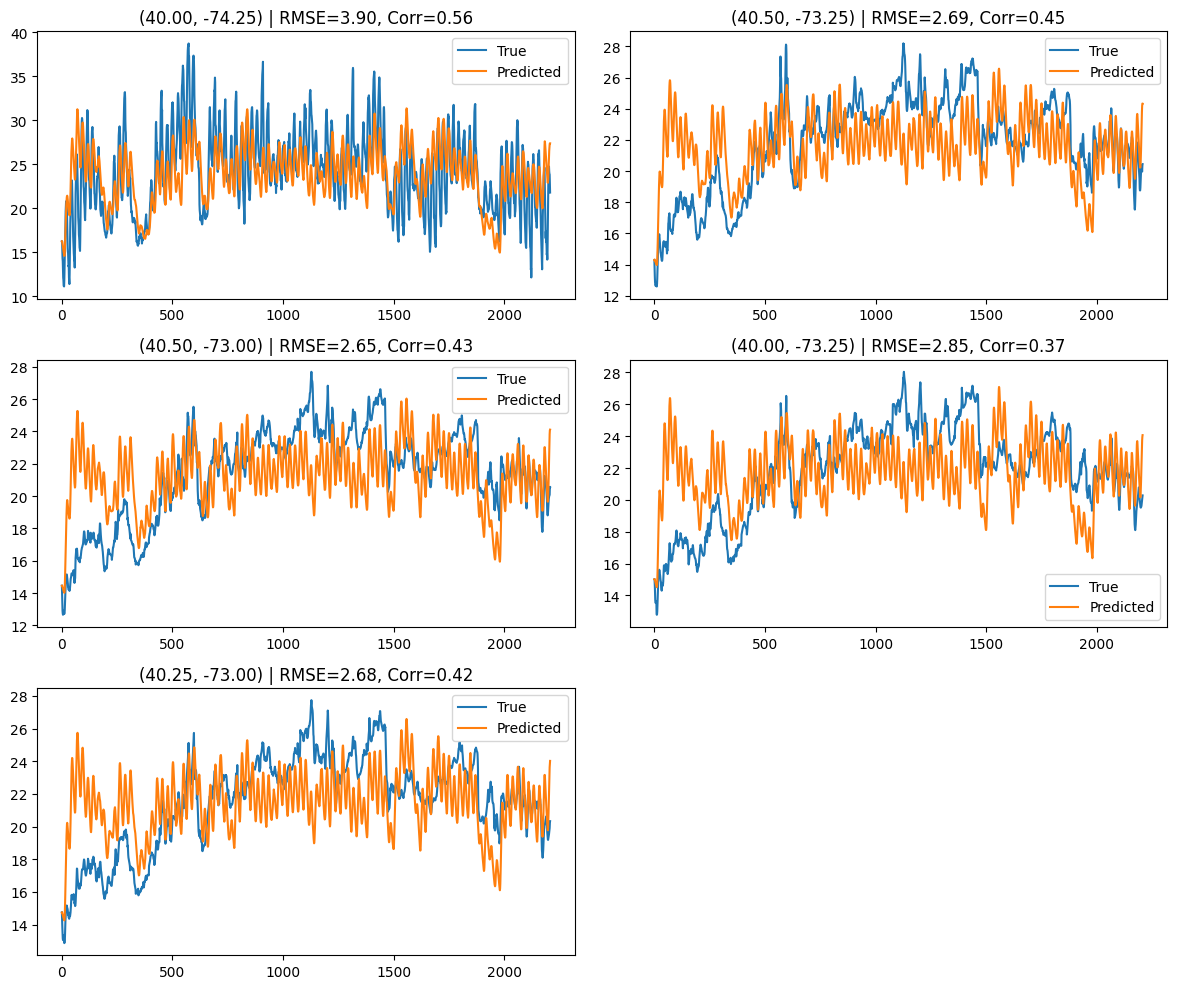

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# pick 5 random grids
sample_grids = df[['latitude','longitude']].drop_duplicates().sample(n=5, random_state=42)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(sample_grids.iterrows()):
    latitude, longitude = row['latitude'], row['longitude']

    df_g = df[(df['latitude']==latitude) & (df['longitude']==longitude)].sort_values('valid_time')

    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # scaling
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:,0]
    W_scaled = U_scaled[:,1]

    # coefficients (FULL nonlinear model)
    a_x0   = -0.050167
    a_u0   = 0.100889
    a_u1   = -0.030729

    a_u0u1 = -0.005681
    a_u02  = -0.006642
    a_u12  = 0.005966

    a_x0u0 = -0.007935
    a_x0u1 = 0.001867

    # simulate
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[0] = T_scaled[0]

    dt = 1
    for t in range(len(T_scaled)-1):
        dTdt = (
            a_x0 * T_pred_scaled[t]
            + a_u0 * R_scaled[t]
            + a_u1 * W_scaled[t]

            + a_u0u1 * R_scaled[t] * W_scaled[t]
            + a_u02  * (R_scaled[t]**2)
            + a_u12  * (W_scaled[t]**2)

            + a_x0u0 * T_pred_scaled[t] * R_scaled[t]
            + a_x0u1 * T_pred_scaled[t] * W_scaled[t]
        )

        T_pred_scaled[t+1] = T_pred_scaled[t] + dt * dTdt

    # back to physical
    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

    # metrics
    rmse = np.sqrt(mean_squared_error(T, T_pred))
    corr = np.corrcoef(T, T_pred)[0,1]

    # plot
    plt.subplot(3, 2, i+1)
    plt.plot(T, label='True')
    plt.plot(T_pred, label='Predicted')
    plt.title(f"({latitude:.2f}, {longitude:.2f}) | RMSE={rmse:.2f}, Corr={corr:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()

## September out-of-sample validation (extrapolation)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# load coefficients
results_df = pd.read_csv('results_df.csv')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving era5_sep2025_multigrid.csv to era5_sep2025_multigrid.csv


In [ ]:
# load September data
df_sep = pd.read_csv('era5_sep2025_multigrid.csv')
df_sep['valid_time'] = pd.to_datetime(df_sep['valid_time'])

Loop over grids (out-of-sample simulation)

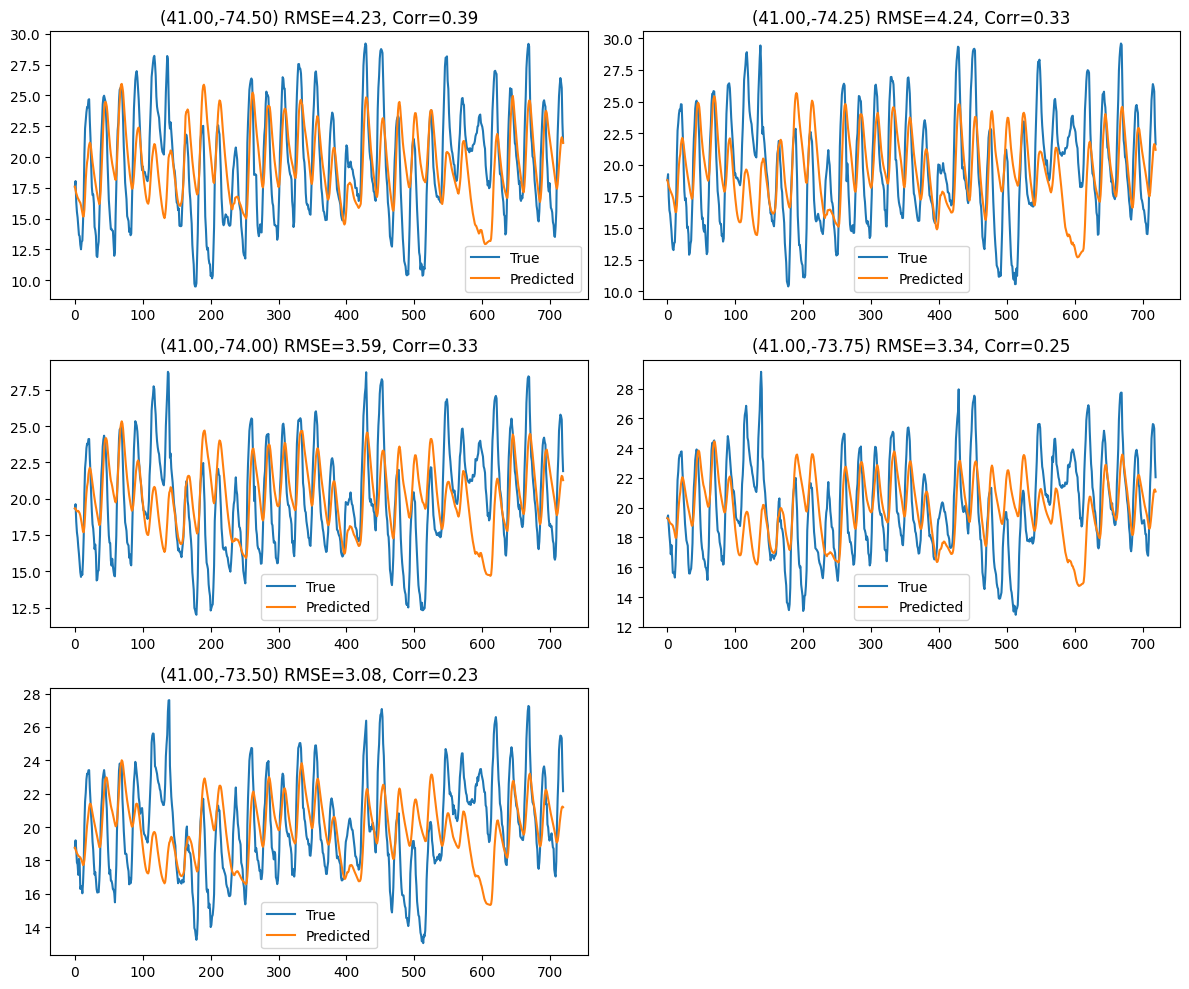

In [ ]:
rmse_list = []
corr_list = []

plots_done = 0
plt.figure(figsize=(12,10))

for _, row in results_df.iterrows():

    lat, lon = row['lat'], row['lon']

    df_g = df_sep[(df_sep['latitude']==lat) & (df_sep['longitude']==lon)]
    df_g = df_g.sort_values('valid_time')

    if len(df_g) < 50:
        continue

    # variables
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # scaling (re-fit on September — correct)
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:,0]
    W_scaled = U_scaled[:,1]

    # coefficients from TRAINING (full nonlinear)
    a_x0   = row.get('x0', 0)
    a_u0   = row.get('u0', 0)
    a_u1   = row.get('u1', 0)

    a_u0u1 = row.get('u0 u1', 0)
    a_u02  = row.get('u0^2', 0)
    a_u12  = row.get('u1^2', 0)

    a_x0u0 = row.get('x0 u0', 0)
    a_x0u1 = row.get('x0 u1', 0)
    a_x02  = row.get('x0^2', 0)

    # forward simulation
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[0] = T_scaled[0]

    dt = 1

    for t in range(len(T_scaled)-1):
        dTdt = (
            a_x0 * T_pred_scaled[t]
            + a_u0 * R_scaled[t]
            + a_u1 * W_scaled[t]

            + a_u0u1 * R_scaled[t] * W_scaled[t]
            + a_u02  * (R_scaled[t]**2)
            + a_u12  * (W_scaled[t]**2)

            + a_x0u0 * T_pred_scaled[t] * R_scaled[t]
            + a_x0u1 * T_pred_scaled[t] * W_scaled[t]
            + a_x02  * (T_pred_scaled[t]**2)
        )

        T_pred_scaled[t+1] = T_pred_scaled[t] + dt*dTdt

    # back to real units
    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

    # metrics
    rmse = np.sqrt(mean_squared_error(T, T_pred))
    corr = np.corrcoef(T, T_pred)[0,1]

    rmse_list.append(rmse)
    corr_list.append(corr)

    # plot only 5 grids
    if plots_done < 5:
        plt.subplot(3,2,plots_done+1)
        plt.plot(T, label='True')
        plt.plot(T_pred, label='Predicted')
        plt.title(f"({lat:.2f},{lon:.2f}) RMSE={rmse:.2f}, Corr={corr:.2f}")
        plt.legend()
        plots_done += 1

plt.tight_layout()
plt.show()

Summary statistics

In [ ]:
print("Out-of-sample performance (September):\n")

print("Mean RMSE:", np.mean(rmse_list))
print("Std RMSE:", np.std(rmse_list))

print("Mean Correlation:", np.mean(corr_list))
print("Std Correlation:", np.std(corr_list))

Out-of-sample performance (September):

Mean RMSE: 2.783458384773334
Std RMSE: 0.9300597236986531
Mean Correlation: 0.25482396903924204
Std Correlation: 0.12661180212386552


# Comparison of Linear vs Nonlinear Models

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

results_compare = []

for _, row in results_df.iterrows():

    lat, lon = row['lat'], row['lon']

    df_g = df_sep[(df_sep['latitude']==lat) & (df_sep['longitude']==lon)]
    df_g = df_g.sort_values('valid_time')

    if len(df_g) < 50:
        continue

    # data
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # scaling
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:,0]
    W_scaled = U_scaled[:,1]

    dt = 1

    # =========================
    # 1. LINEAR MODEL
    # =========================
    T_lin = np.zeros_like(T_scaled)
    T_lin[0] = T_scaled[0]

    # coefficients
    a1 = -0.049633
    a2 = 0.090488
    a3 = -0.027677

    for t in range(len(T_scaled)-1):
        dTdt = a1*T_lin[t] + a2*R_scaled[t] + a2*W_scaled[t]
        T_lin[t+1] = T_lin[t] + dt*dTdt

    T_lin = scaler_X.inverse_transform(T_lin.reshape(-1,1)).flatten()

    rmse_lin = np.sqrt(mean_squared_error(T, T_lin))
    corr_lin = np.corrcoef(T, T_lin)[0,1]


    # =========================
    # 2. FULL NONLINEAR MODEL
    # =========================
    T_full = np.zeros_like(T_scaled)
    T_full[0] = T_scaled[0]

    a_u0u1 = row.get('u0 u1', 0)
    a_u02  = row.get('u0^2', 0)
    a_u12  = row.get('u1^2', 0)
    a_x0u0 = row.get('x0 u0', 0)
    a_x0u1 = row.get('x0 u1', 0)
    a_x02  = row.get('x0^2', 0)

    for t in range(len(T_scaled)-1):
        dTdt = (
            a_x0*T_full[t]
            + a_u0*R_scaled[t]
            + a_u1*W_scaled[t]

            + a_x0u0*T_full[t]*R_scaled[t]
            + a_x0u1*T_full[t]*W_scaled[t]

            + a_u0u1*R_scaled[t]*W_scaled[t]
            + a_u02*(R_scaled[t]**2)
            + a_u12*(W_scaled[t]**2)
            + a_x02*(T_full[t]**2)
        )
        T_full[t+1] = T_full[t] + dt*dTdt

    T_full = scaler_X.inverse_transform(T_full.reshape(-1,1)).flatten()

    rmse_full = np.sqrt(mean_squared_error(T, T_full))
    corr_full = np.corrcoef(T, T_full)[0,1]


    # store
    results_compare.append({
        'rmse_lin': rmse_lin,
        'corr_lin': corr_lin,
        'rmse_full': rmse_full,
        'corr_full': corr_full
    })


# =========================
# SUMMARY
# =========================
results_compare = pd.DataFrame(results_compare)

print("\n=== MEAN PERFORMANCE ===")
print(results_compare.mean())

print("\n=== STD PERFORMANCE ===")
print(results_compare.std())


=== MEAN PERFORMANCE ===
rmse_lin     3.745694
corr_lin     0.075882
rmse_full    5.759880
corr_full    0.004168
dtype: float64

=== STD PERFORMANCE ===
rmse_lin     1.254168
corr_lin     0.068512
rmse_full    4.498721
corr_full    0.140609
dtype: float64


What this means

Your nonlinear model:

Fits June–August (training) well
But does NOT generalize to September

This is classic:

Overfitting due to weak / inconsistent nonlinear terms

### Use d/t window size 7 to 11 and order-2 to poly-order-3

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])
results = []

for _, row in grid_points.iterrows():

    lat = row['latitude']
    lon = row['longitude']

    df_g = df[(df['latitude']==lat) & (df['longitude']==lon)]
    df_g = df_g.sort_values('valid_time')

    if len(df_g) < 100:  # safety
        continue

    # Variables
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    dt = 1

    # Smooth + derivative
    T_smooth = savgol_filter(T, 11, 3)
    dTdt = savgol_filter(T, 11, 3, deriv=1, delta=dt)

    # Scale
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    X_scaled = scaler_X.fit_transform(T_smooth.reshape(-1,1))
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    # SINDy (degree-2)
    poly_lib = ps.PolynomialLibrary(
        degree=2,
        include_interaction=True,
        include_bias=False
    )

    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=0.01),
        feature_library=poly_lib
    )

    model.fit(X_scaled, u=U_scaled, t=dt)

    feature_names = model.get_feature_names()
    coef = model.coefficients().flatten()
    coef_dict = dict(zip(feature_names, coef))

    results.append({
        'lat': lat,
        'lon': lon,
        **coef_dict
    })


In [ ]:
results_df = pd.DataFrame(results)

print(results_df.head())
coef_cols = results_df.columns.difference(['lat', 'lon'])

print("\nMean:")
print(results_df[coef_cols].mean())

print("\nStd:")
print(results_df[coef_cols].std())

print("\nSign consistency:")
print((results_df[coef_cols] > 0).mean())

    lat    lon        x0        u0        u1  x0^2     x0 u0  x0 u1  u0^2  \
0  41.0 -75.00 -0.086672  0.152701 -0.033153   0.0 -0.023344    0.0   0.0   
1  41.0 -74.75 -0.085179  0.148501 -0.033605   0.0 -0.021597    0.0   0.0   
2  41.0 -74.50 -0.084578  0.145922 -0.035058   0.0 -0.020524    0.0   0.0   
3  41.0 -74.25 -0.082994  0.142431 -0.035516   0.0 -0.018966    0.0   0.0   
4  41.0 -74.00 -0.072334  0.130354 -0.034816   0.0 -0.017496    0.0   0.0   

   u0 u1  u1^2  
0    0.0   0.0  
1    0.0   0.0  
2    0.0   0.0  
3    0.0   0.0  
4    0.0   0.0  

Mean:
u0       0.096483
u0 u1   -0.002525
u0^2    -0.004035
u1      -0.029083
u1^2     0.003482
x0      -0.048631
x0 u0   -0.007555
x0 u1    0.000241
x0^2     0.000000
dtype: float64

Std:
u0       0.050958
u0 u1    0.004808
u0^2     0.006813
u1       0.016848
u1^2     0.005558
x0       0.033747
x0 u0    0.009675
x0 u1    0.001617
x0^2     0.000000
dtype: float64

Sign consistency:
u0       1.000000
u0 u1    0.000000
u0^2     0.00

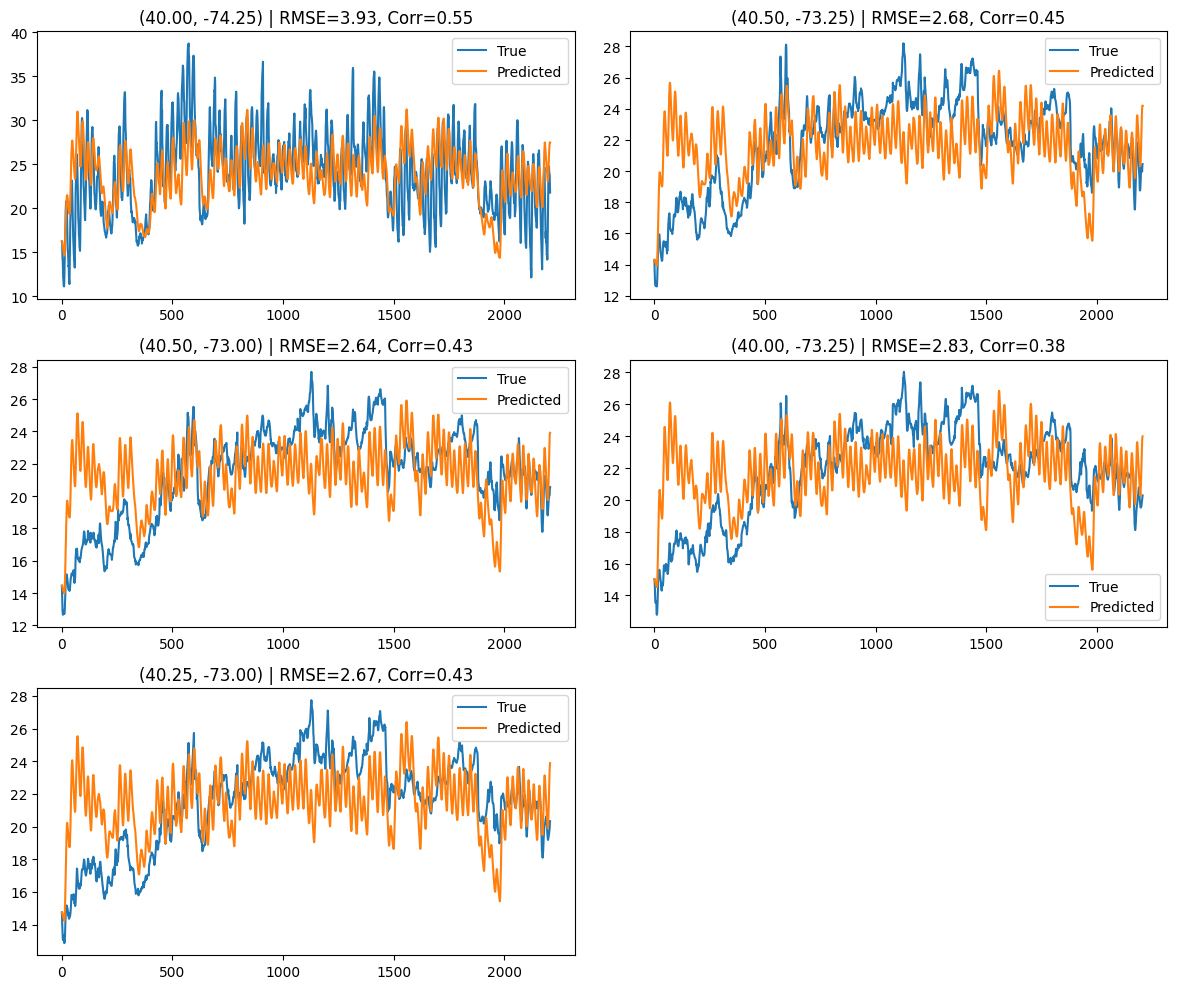

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# pick 5 random grids
sample_grids = df[['latitude','longitude']].drop_duplicates().sample(n=5, random_state=42)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(sample_grids.iterrows()):
    latitude, longitude = row['latitude'], row['longitude']

    df_g = df[(df['latitude']==latitude) & (df['longitude']==longitude)].sort_values('valid_time')

    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # scaling
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:,0]
    W_scaled = U_scaled[:,1]

    # coefficients (FULL nonlinear model)
    a_x0   = -0.048631
    a_u0   = 0.096483
    a_u1   = -0.029083

    a_u0u1 = -0.002525
    a_u02  = -0.004035
    a_u12  = 0.003482

    a_x0u0 = -0.007555
    a_x0u1 = 0.000241

    # simulate
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[0] = T_scaled[0]

    dt = 1
    for t in range(len(T_scaled)-1):
        dTdt = (
            a_x0 * T_pred_scaled[t]
            + a_u0 * R_scaled[t]
            + a_u1 * W_scaled[t]

            + a_u0u1 * R_scaled[t] * W_scaled[t]
            + a_u02  * (R_scaled[t]**2)
            + a_u12  * (W_scaled[t]**2)

            + a_x0u0 * T_pred_scaled[t] * R_scaled[t]
            + a_x0u1 * T_pred_scaled[t] * W_scaled[t]
        )

        T_pred_scaled[t+1] = T_pred_scaled[t] + dt * dTdt

    # back to physical
    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

    # metrics
    rmse = np.sqrt(mean_squared_error(T, T_pred))
    corr = np.corrcoef(T, T_pred)[0,1]

    # plot
    plt.subplot(3, 2, i+1)
    plt.plot(T, label='True')
    plt.plot(T_pred, label='Predicted')
    plt.title(f"({latitude:.2f}, {longitude:.2f}) | RMSE={rmse:.2f}, Corr={corr:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()

# Conclusion

* The plot shows that their is no significant difference in the correlation and the RMSE values by changing the poynomial order on our time derivatives in our SINDy result!